In [1]:
import os
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import shapely

from belo_horizonte.bounds import load_bounds
from belo_horizonte.temperature import get_lst
from belo_horizonte.utils import clamp_bounds

/Users/rodolfofigueroa/Documents/belo_horizonte/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
ee.Initialize()

In [3]:
data_path = Path("./data")
generated_path = Path(os.environ["DATA_PATH"]) / "generated"

In [ ]:
bounds_ee, bounds = load_bounds(data_path=data_path, return_geometry=True)

lst_proj = get_lst(bounds_ee).projection()
crs = str(lst_proj.crs().getInfo())

In [5]:
df_zones = (
    gpd.read_file(data_path / "PL_limite_area_verde_publica.zip")
    .drop(columns=["fid"])
    .assign(ID_AREA_VE=lambda df: df["ID_AREA_VE"].astype(int))
    .set_index("ID_AREA_VE")
    .sort_index()
    .to_crs(crs)
)

In [6]:
df_zones_joined = gpd.GeoDataFrame(
    geometry=list(df_zones.buffer(50).union_all().geoms),
    crs=crs,
).reset_index(names="zone_id")

In [7]:
def get_zone_sample_points(zone: pd.Series) -> gpd.GeoDataFrame:
    zone_bounds = clamp_bounds(*zone["geometry"].bounds, scale=30)
    zone_points = gpd.GeoDataFrame(
        geometry=[
            shapely.Point(x, y)
            for x in np.arange(zone_bounds[0], zone_bounds[2], 30)
            for y in np.arange(zone_bounds[1], zone_bounds[3], 30)
        ],
        crs=crs,
    )
    return zone_points[zone_points.intersects(zone["geometry"])].assign(
        zone_id=zone["zone_id"],
    )

In [8]:
df_sample_points = pd.concat(
    [get_zone_sample_points(zone) for _, zone in df_zones_joined.iterrows()],
    ignore_index=True,
)

col_sample_points = geemap.geopandas_to_ee(df_sample_points.to_crs("EPSG:4326"))

# Canopy

In [9]:
img_canopy = (
    ee.ImageCollection("projects/sat-io/open-datasets/facebook/meta-canopy-height")
    .filterBounds(bounds_ee)
    .first()
    .gte(ee.Number(3))
)

In [ ]:
img_canopy_resampled = img_canopy.reduceResolution(ee.Reducer.mean(), maxPixels=1024)

img_canopy_resampled.sampleRegions(
    col_sample_points,
    projection=lst_proj,
    scale=lst_proj.nominalScale(),
    geometries=False,
).getInfo()

EEException: Reprojection output too large (14537x17668 pixels).

In [12]:
sampled = ee.data.computeFeatures(
    {
        "expression": img_canopy_resampled.sampleRegions(
            col_sample_points,
            projection=lst_proj,
            scale=lst_proj.nominalScale(),
            geometries=False,
        ),
        "fileFormat": "GEOPANDAS_GEODATAFRAME",
    }
)

EEException: Reprojection output too large (14537x17668 pixels).

<Axes: xlabel='cover_code', ylabel='Density'>

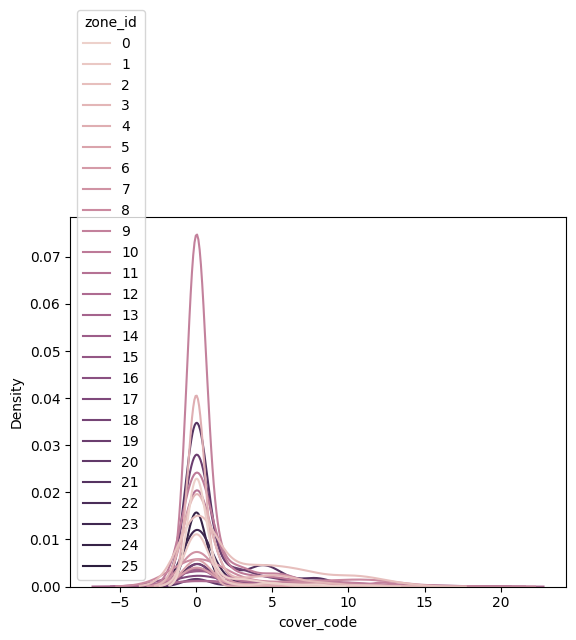

In [40]:
sns.kdeplot(sampled, x="cover_code", hue="zone_id")